# EEGMAT improved feature masking

This follow-up keeps the completed baseline notebook unchanged. It tests
utility-aware, stability-averaged, iterative feature masking only.

At each masking step, feature importance is re-estimated from outer-training
subjects. Features receive a high masking score when they are important for
subject identity but comparatively unimportant for rest-vs-arithmetic utility.

In [1]:
from google.colab import drive
drive.mount("/content/drive")
get_ipython().system('pip -q install "scikit-learn>=1.4,<2" "scipy>=1.11" matplotlib')

Mounted at /content/drive


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

RANDOM_STATE = 42
N_RANKING_MODELS = 3
MASK_PERCENTAGES = [0, 10, 20, 30, 40, 50, 60, 70, 80]

BASE_DIR = Path("/content/drive/MyDrive/URV_Datasets/eegmat")
CACHE_DIR = BASE_DIR / "clean_eeg_only_cache"
RESULTS_DIR = BASE_DIR / "results"

FEATURE_FILE = CACHE_DIR / "eegmat_clean_features_2s_250hz_1_80hz_balanced.npz"
METADATA_FILE = CACHE_DIR / "eegmat_clean_raw_windows_2s_250hz_1_80hz_balanced_metadata.csv"
SPLITS_FILE = CACHE_DIR / "eegmat_clean_fixed_splits.json"
STANDARD_TRADEOFF_FILE = RESULTS_DIR / "eegmat_gaussian_feature_masking_tradeoff.csv"

DETAIL_FILE = RESULTS_DIR / "eegmat_improved_feature_masking_detailed.csv"
SUMMARY_FILE = RESULTS_DIR / "eegmat_improved_feature_masking_summary.csv"
SELECTION_FILE = RESULTS_DIR / "eegmat_improved_feature_masking_selections.csv"
COMPARISON_FILE = RESULTS_DIR / "eegmat_standard_vs_improved_feature_masking.csv"
FIGURE_FILE = RESULTS_DIR / "eegmat_standard_vs_improved_feature_masking.png"
RUN_FILE = RESULTS_DIR / "eegmat_improved_feature_masking_run.json"

for required in [FEATURE_FILE, METADATA_FILE, SPLITS_FILE]:
    assert required.exists(), f"Missing required clean-baseline file: {required}"

X = np.load(FEATURE_FILE, allow_pickle=False)["X_features"].astype(np.float32)
metadata = pd.read_csv(METADATA_FILE)
with open(SPLITS_FILE, "r") as handle:
    split_config = json.load(handle)

splits = split_config["utility_splits"]
y_condition = metadata["condition"].to_numpy(dtype=np.int64)
subject_ids = metadata["subject_id"].to_numpy()

assert X.shape == (2232, 285), X.shape
assert len(metadata) == len(X)
assert np.isfinite(X).all()

print("Features:", X.shape)
print("Subjects:", metadata["subject_id"].nunique())
print("Outer folds:", len(splits))

Features: (2232, 285)
Subjects: 36
Outer folds: 5


## Models, metrics, and stable importance estimation

In [3]:
def utility_model():
    return RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def privacy_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])


def metrics(y_true, prediction):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "weighted_f1": f1_score(y_true, prediction, average="weighted"),
    }


def stable_rf_importance(X_train, y_train, seed_offset):
    importances = []
    for repeat in range(N_RANKING_MODELS):
        model = RandomForestClassifier(
            n_estimators=300,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE + seed_offset + repeat,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        importances.append(model.feature_importances_)
    return np.mean(importances, axis=0)


def evaluate(X_masked, fold, train_idx, test_idx, mask_percentage, n_masked):
    rows = []

    classifier = utility_model()
    classifier.fit(X_masked[train_idx], y_condition[train_idx])
    prediction = classifier.predict(X_masked[test_idx])
    rows.append({
        "method": "utility_aware_iterative_masking",
        "fold": fold,
        "mask_percentage": mask_percentage,
        "n_masked": n_masked,
        "task": "utility",
        "direction": "condition classification",
        "n_classes": 2,
        "chance_accuracy": 0.5,
        **metrics(y_condition[test_idx], prediction),
    })

    heldout_subjects = subject_ids[test_idx]
    encoder = LabelEncoder()
    heldout_labels = encoder.fit_transform(heldout_subjects)
    n_subjects = len(encoder.classes_)

    for train_condition, test_condition, direction in [
        (0, 1, "rest -> arithmetic"),
        (1, 0, "arithmetic -> rest"),
    ]:
        train_local = np.flatnonzero(y_condition[test_idx] == train_condition)
        test_local = np.flatnonzero(y_condition[test_idx] == test_condition)

        attacker = privacy_model()
        attacker.fit(X_masked[test_idx][train_local], heldout_labels[train_local])
        attack_prediction = attacker.predict(X_masked[test_idx][test_local])

        rows.append({
            "method": "utility_aware_iterative_masking",
            "fold": fold,
            "mask_percentage": mask_percentage,
            "n_masked": n_masked,
            "task": "privacy",
            "direction": direction,
            "n_classes": n_subjects,
            "chance_accuracy": 1 / n_subjects,
            **metrics(heldout_labels[test_local], attack_prediction),
        })

    return rows

## Iterative, utility-aware masking

For each fold:

1. Average identity importance across three Random Forests.
2. Average utility importance across three Random Forests.
3. Rank unmasked features by:

`privacy importance / (utility importance + regularizer)`

4. Mask the next batch using outer-training feature means.
5. Refit both importance models before selecting the next batch.

In [4]:
all_rows = []
selection_rows = []
n_features = X.shape[1]

for split in splits:
    fold = int(split["fold"])
    train_idx = np.asarray(split["train_window_ids"], dtype=np.int64)
    test_idx = np.asarray(split["test_window_ids"], dtype=np.int64)
    assert set(subject_ids[train_idx]).isdisjoint(set(subject_ids[test_idx]))

    subject_encoder = LabelEncoder()
    privacy_train_labels = subject_encoder.fit_transform(subject_ids[train_idx])
    train_means = X[train_idx].mean(axis=0)

    selected = []
    X_masked = X.copy()

    for mask_percentage in MASK_PERCENTAGES:
        target_count = int(round(n_features * mask_percentage / 100.0))

        if target_count > len(selected):
            privacy_importance = stable_rf_importance(
                X_masked[train_idx], privacy_train_labels, seed_offset=fold * 100
            )
            utility_importance = stable_rf_importance(
                X_masked[train_idx], y_condition[train_idx], seed_offset=fold * 100 + 50
            )

            # Prevent tiny utility importances from producing unstable ratios.
            regularizer = 0.10 * np.mean(utility_importance)
            mask_score = privacy_importance / (utility_importance + regularizer)
            mask_score[np.asarray(selected, dtype=np.int64)] = -np.inf

            number_to_add = target_count - len(selected)
            new_features = np.argsort(mask_score)[::-1][:number_to_add]

            for feature_index in new_features:
                selection_rows.append({
                    "fold": fold,
                    "selected_at_mask_percentage": mask_percentage,
                    "selection_order": len(selected) + 1,
                    "feature_index": int(feature_index),
                    "privacy_importance": float(privacy_importance[feature_index]),
                    "utility_importance": float(utility_importance[feature_index]),
                    "mask_score": float(mask_score[feature_index]),
                })
                selected.append(int(feature_index))

            X_masked[:, new_features] = train_means[new_features]

        print(
            f"Fold {fold}: mask={mask_percentage}% "
            f"({len(selected)}/{n_features} features)"
        )
        all_rows.extend(evaluate(
            X_masked,
            fold,
            train_idx,
            test_idx,
            mask_percentage,
            len(selected),
        ))

results = pd.DataFrame(all_rows)
selections = pd.DataFrame(selection_rows)

Fold 1: mask=0% (0/285 features)
Fold 1: mask=10% (28/285 features)
Fold 1: mask=20% (57/285 features)
Fold 1: mask=30% (86/285 features)
Fold 1: mask=40% (114/285 features)
Fold 1: mask=50% (142/285 features)
Fold 1: mask=60% (171/285 features)
Fold 1: mask=70% (200/285 features)
Fold 1: mask=80% (228/285 features)
Fold 2: mask=0% (0/285 features)
Fold 2: mask=10% (28/285 features)
Fold 2: mask=20% (57/285 features)
Fold 2: mask=30% (86/285 features)
Fold 2: mask=40% (114/285 features)
Fold 2: mask=50% (142/285 features)
Fold 2: mask=60% (171/285 features)
Fold 2: mask=70% (200/285 features)
Fold 2: mask=80% (228/285 features)
Fold 3: mask=0% (0/285 features)
Fold 3: mask=10% (28/285 features)
Fold 3: mask=20% (57/285 features)
Fold 3: mask=30% (86/285 features)
Fold 3: mask=40% (114/285 features)
Fold 3: mask=50% (142/285 features)
Fold 3: mask=60% (171/285 features)
Fold 3: mask=70% (200/285 features)
Fold 3: mask=80% (228/285 features)
Fold 4: mask=0% (0/285 features)
Fold 4: mask=

## Baseline-relative changes and summaries

In [5]:
reference = results[results["mask_percentage"] == 0][
    ["fold", "task", "direction", "balanced_accuracy", "chance_accuracy"]
].rename(columns={
    "balanced_accuracy": "baseline_balanced_accuracy",
    "chance_accuracy": "baseline_chance_accuracy",
})

results = results.merge(reference, on=["fold", "task", "direction"], how="left")
results["utility_loss"] = np.where(
    results["task"] == "utility",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)
results["privacy_reduction"] = np.where(
    results["task"] == "privacy",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)

denominator = results["baseline_balanced_accuracy"] - results["baseline_chance_accuracy"]
results["normalized_privacy_reduction"] = np.where(
    (results["task"] == "privacy") & (denominator > 0),
    results["privacy_reduction"] / denominator,
    np.nan,
)

summary = (
    results
    .groupby(["method", "mask_percentage", "n_masked", "task"], as_index=False)
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        chance_accuracy_mean=("chance_accuracy", "mean"),
        utility_loss_mean=("utility_loss", "mean"),
        privacy_reduction_mean=("privacy_reduction", "mean"),
        normalized_privacy_reduction_mean=("normalized_privacy_reduction", "mean"),
        n_evaluations=("balanced_accuracy", "count"),
    )
)

utility_summary = summary[summary["task"] == "utility"].drop(columns="task")
privacy_summary = summary[summary["task"] == "privacy"].drop(columns="task")
improved_tradeoff = utility_summary.merge(
    privacy_summary,
    on=["method", "mask_percentage", "n_masked"],
    suffixes=("_utility", "_privacy"),
)

results.to_csv(DETAIL_FILE, index=False)
summary.to_csv(SUMMARY_FILE, index=False)
selections.to_csv(SELECTION_FILE, index=False)

display(improved_tradeoff[[
    "mask_percentage",
    "n_masked",
    "balanced_accuracy_mean_utility",
    "utility_loss_mean_utility",
    "balanced_accuracy_mean_privacy",
    "privacy_reduction_mean_privacy",
    "normalized_privacy_reduction_mean_privacy",
]])

,mask_percentage,n_masked,balanced_accuracy_mean_utility,utility_loss_mean_utility,balanced_accuracy_mean_privacy,privacy_reduction_mean_privacy,normalized_privacy_reduction_mean_privacy
0,0,0,0.716993,0.000000,0.696083,0.000000,0.000000
1,10,28,0.723675,-0.006682,0.680242,0.015841,0.020043
2,20,57,0.717800,-0.000806,0.664171,0.031912,0.035713
3,30,86,0.716647,0.000346,0.630472,0.065611,0.096575
4,40,114,0.725288,-0.008295,0.603975,0.092108,0.153576
5,50,142,0.730818,-0.013825,0.561348,0.134735,0.243214
6,60,171,0.720565,-0.003571,0.533122,0.162961,0.287618
7,70,200,0.708180,0.008813,0.478629,0.217454,0.385291
8,80,228,0.684677,0.032316,0.412500,0.283583,0.479902


## Compare against the original identity-only feature masking

,masking_method,mask_percentage,n_masked,balanced_accuracy_mean_utility,utility_loss_mean_utility,balanced_accuracy_mean_privacy,privacy_reduction_mean_privacy,normalized_privacy_reduction_mean_privacy
0,identity-only masking,0,0,0.716993,0.000000,0.696083,0.000000,0.000000
1,identity-only masking,5,14,0.718088,-0.001094,0.698272,-0.002189,-0.006993
2,identity-only masking,10,28,0.694009,0.022984,0.671832,0.024251,0.044195
3,identity-only masking,20,57,0.690783,0.026210,0.664055,0.032028,0.036883
4,identity-only masking,30,86,0.675806,0.041187,0.651267,0.044816,0.052441
5,identity-only masking,40,114,0.666763,0.050230,0.642454,0.053629,0.056642
6,identity-only masking,50,142,0.670104,0.046889,0.629493,0.066590,0.046031
7,identity-only masking,60,171,0.648387,0.068606,0.600864,0.095219,0.113470
8,identity-only masking,70,200,0.626555,0.090438,0.551094,0.144988,0.205399
9,identity-only masking,80,228,0.600806,0.116187,0.470968,0.225115,0.342772


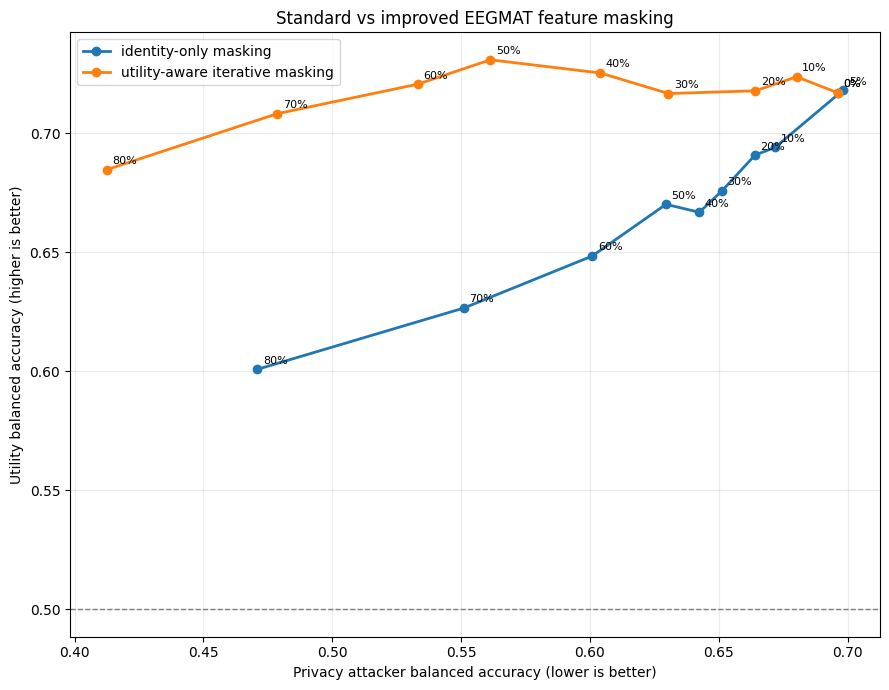

Saved detailed results: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_improved_feature_masking_detailed.csv
Saved summary: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_improved_feature_masking_summary.csv
Saved feature selections: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_improved_feature_masking_selections.csv
Saved comparison: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_standard_vs_improved_feature_masking.csv
Saved figure: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_standard_vs_improved_feature_masking.png
Saved run metadata: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_improved_feature_masking_run.json


In [6]:
assert STANDARD_TRADEOFF_FILE.exists(), "Run the original masking notebook first."
standard = pd.read_csv(STANDARD_TRADEOFF_FILE)
standard = standard[standard["method"] == "feature_masking"].copy()
standard["mask_percentage"] = standard["strength"].astype(int)
standard["masking_method"] = "identity-only masking"

improved = improved_tradeoff.copy()
improved["masking_method"] = "utility-aware iterative masking"

comparison_columns = [
    "masking_method",
    "mask_percentage",
    "n_masked",
    "balanced_accuracy_mean_utility",
    "utility_loss_mean_utility",
    "balanced_accuracy_mean_privacy",
    "privacy_reduction_mean_privacy",
    "normalized_privacy_reduction_mean_privacy",
]

comparison = pd.concat(
    [standard[comparison_columns], improved[comparison_columns]],
    ignore_index=True,
)
comparison.to_csv(COMPARISON_FILE, index=False)
display(comparison)

plt.figure(figsize=(9, 7))
for method, group in comparison.groupby("masking_method"):
    group = group.sort_values("mask_percentage")
    plt.plot(
        group["balanced_accuracy_mean_privacy"],
        group["balanced_accuracy_mean_utility"],
        marker="o",
        linewidth=2,
        label=method,
    )
    for row in group.itertuples(index=False):
        plt.annotate(
            f"{row.mask_percentage}%",
            (row.balanced_accuracy_mean_privacy,
             row.balanced_accuracy_mean_utility),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Privacy attacker balanced accuracy (lower is better)")
plt.ylabel("Utility balanced accuracy (higher is better)")
plt.title("Standard vs improved EEGMAT feature masking")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FILE, dpi=200, bbox_inches="tight")
plt.show()

run_summary = {
    "dataset": "EEGMAT clean EEG-only 1-80 Hz",
    "method": "utility-aware stability-averaged iterative feature masking",
    "outer_folds": len(splits),
    "ranking_models_per_task_per_step": N_RANKING_MODELS,
    "mask_percentages": MASK_PERCENTAGES,
    "selection_uses_outer_training_subjects_only": True,
    "files": {
        "detailed": str(DETAIL_FILE),
        "summary": str(SUMMARY_FILE),
        "selections": str(SELECTION_FILE),
        "comparison": str(COMPARISON_FILE),
        "figure": str(FIGURE_FILE),
    },
}
with open(RUN_FILE, "w") as handle:
    json.dump(run_summary, handle, indent=2)

print("Saved detailed results:", DETAIL_FILE)
print("Saved summary:", SUMMARY_FILE)
print("Saved feature selections:", SELECTION_FILE)
print("Saved comparison:", COMPARISON_FILE)
print("Saved figure:", FIGURE_FILE)
print("Saved run metadata:", RUN_FILE)